In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Weekday,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday,7,False


In [8]:
monthly = (
    df.groupby(
        pd.Grouper(
            key="InvoiceDate",
            freq="ME"
        )
    )["Revenue"]
    .sum()
    .reset_index()
)

monthly

,InvoiceDate,Revenue
0,2009-12-31,796648.500
1,2010-01-31,622479.502
2,2010-02-28,531265.366
3,2010-03-31,763247.241
4,2010-04-30,587926.692
5,2010-05-31,613270.720
6,2010-06-30,677073.870
7,2010-07-31,573333.690
8,2010-08-31,654774.390
9,2010-09-30,851105.961


In [9]:
monthly["MonthNumber"] = range(1, len(monthly) + 1)

monthly

,InvoiceDate,Revenue,MonthNumber
0,2009-12-31,796648.500,1
1,2010-01-31,622479.502,2
2,2010-02-28,531265.366,3
3,2010-03-31,763247.241,4
4,2010-04-30,587926.692,5
5,2010-05-31,613270.720,6
6,2010-06-30,677073.870,7
7,2010-07-31,573333.690,8
8,2010-08-31,654774.390,9
9,2010-09-30,851105.961,10


In [10]:
X = monthly[["MonthNumber"]]
y = monthly["Revenue"]

model = LinearRegression()
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [11]:
future = pd.DataFrame({
    "MonthNumber": range(
        len(monthly) + 1,
        len(monthly) + 7
    )
})

future["PredictedRevenue"] = model.predict(future)

future

,MonthNumber,PredictedRevenue
0,14,879206.348077
1,15,900348.182813
2,16,921490.017549
3,17,942631.852286
4,18,963773.687022
5,19,984915.521758


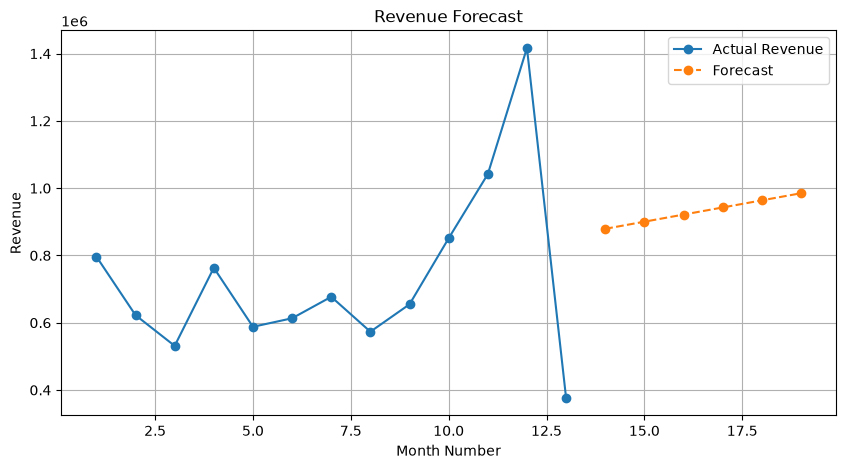

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly["MonthNumber"],
    monthly["Revenue"],
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    future["MonthNumber"],
    future["PredictedRevenue"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.xlabel("Month Number")
plt.ylabel("Revenue")
plt.title("Revenue Forecast")
plt.legend()
plt.grid(True)

plt.show()